  <h1 style="margin: 0;"><strong>Data Mining Project: Amazing International Airlines Inc.</strong></h1>
  <h2 style="margin: 0;"><strong>Part 2/2: Clustering</strong></h2>
</div>

<div style="text-align: left; margin-top: 15px;">
  <p style="margin: 0;"><strong>Group 51:</strong></p>
  <ul style="margin: 0; padding-left: 20px;">
    <li>André Ferreira | 20250398</li>
    <li>Fausto Gomes | 20221915</li>
    <li>Maria Francisca Gonçalves | 20221942</li>
    <li>Miguel Matos | 20221925</li>
  </ul>
</div>


## <h2 style="color: #ffffffff; background-color: #1d4e81; text-align: center; padding: 6px; font-family: 'Arial';">0. Context</h2>

ADICIONAR TEXTO !!!!!!!!!!!

## <h2 style="color: #ffffffff; background-color: #1d4e81; text-align: center; padding: 6px; font-family: 'Arial';">1. Libraries & Data Importation</h2>

In [1]:
import os
import sys
import warnings

import sys
sys.path.append('../')

# Suppress warnings
warnings.filterwarnings('ignore')

### Basic Libraries
import numpy as np
import pandas as pd

### Sklearn
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

NOTA: PASSAR ISTO TUDO PARA .PY !!!

In [2]:
#FUNÇOES

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
from PIL import Image
import urllib
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import umap
import math

def set_plot_properties(ax, x_label, y_label, y_lim=[]):
    """
    Set properties of a plot axis.

    Args:
        ax (matplotlib.axes.Axes): The axis object of the plot.
        x_label (str): The label for the x-axis.
        y_label (str): The label for the y-axis.
        y_lim (list, optional): The limits for the y-axis. Defaults to [].

    Returns:
        None
    """
    ax.set_xlabel(x_label)  # Set the label for the x-axis
    ax.set_ylabel(y_label)  # Set the label for the y-axis
    if len(y_lim) != 0:
        ax.set_ylim(y_lim)  # Set the limits for the y-axis if provided


def plot_inertia_and_silhouette(data, k_min=2, k_max=15):
    """
    Plot the inertia (dispersion) and silhouette score for different numbers of clusters.

    Args:
        data (numpy.ndarray or pandas.DataFrame): The input data for clustering.
        k_min (int, optional): The minimum number of clusters to evaluate. Defaults to 2.
        k_max (int, optional): The maximum number of clusters to evaluate. Defaults to 15.

    Returns:
        None
    """
    dispersions = []
    scores = []

    k_clusters = range(k_min, k_max + 1)

    for k in k_clusters:
        kmeans = KMeans(n_clusters=k, random_state=0).fit(data)
        dispersions.append(kmeans.inertia_)  # Calculate the dispersion (inertia) for each number of clusters
        kmeans.predict(data)
        scores.append(silhouette_score(data, kmeans.labels_, metric='euclidean'))  # Calculate the silhouette score

    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.plot(k_clusters, dispersions, marker='o')  # Plot the inertia (dispersion)
    set_plot_properties(ax1, 'Number of clusters', 'Dispersion (inertia)')
    ax2.plot(k_clusters, scores, marker='o')  # Plot the silhouette score
    set_plot_properties(ax2, 'Number of clusters', 'Silhouette score')

    plt.show()


def plot_dendrogram(data, linkage_method, cut_line=None):
    """
    Plot a dendrogram for hierarchical clustering.

    Args:
        data (numpy.ndarray or pandas.DataFrame): The input data for clustering.
        linkage_method (str): The linkage method used for clustering.
        cut_line (float, optional): The threshold value to cut the dendrogram. Defaults to None.

    Returns:
        None
    """
    # Fit the AgglomerativeClustering model
    model = AgglomerativeClustering(linkage=linkage_method, distance_threshold=0, n_clusters=None).fit(data)

    # Create the plot
    fig, ax = plt.subplots()
    plt.title('Hierarchical Clustering Dendrogram')

    # Create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # Leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    # Create the linkage matrix
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)

    # Plot the dendrogram
    dendrogram(linkage_matrix, truncate_mode='level', p=50)

    # Add a cut line if provided
    if cut_line is not None:
        plt.axhline(y=cut_line, color='black', linestyle='-')

    # Display the plot
    plt.show()


def plot_umap_projections(people, cluster_columns, n_components=2, random_state=42):
    """
    Generates UMAP projections for multiple clustering methods and plots them in a grid.

    Parameters:
    people (DataFrame): The input data containing the features and cluster assignments.
    cluster_columns (list of str): The list of column names containing cluster assignments for each method.
    n_components (int): Number of dimensions for UMAP projection. Default is 2.
    random_state (int): Random state for UMAP. Default is 42.
    """
    # Check if at least one cluster column is provided
    if len(cluster_columns) < 1:
        raise ValueError("At least one cluster column must be provided.")

    # Determine the layout of subplots
    num_plots = len(cluster_columns)
    num_rows = math.ceil(math.sqrt(num_plots))
    num_cols = math.ceil(num_plots / num_rows)

    # Create the subplots
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(16, 12))
    axs = axs.flatten()  # Flatten the array of axes

    for i, cluster_column in enumerate(cluster_columns):
        # Check if the necessary columns are present in the dataframe
        if cluster_column not in people.columns:
            raise ValueError(f"Cluster column '{cluster_column}' not found in the data.")

        # Separate features and clusters
        features = people.drop(columns=[cluster_column])
        clusters = people[cluster_column]

        # Perform UMAP
        reducer = umap.UMAP(n_components=n_components, random_state=random_state)
        umap_embedding = reducer.fit_transform(features)

        # Plot the UMAP embedding
        scatter = axs[i].scatter(
            umap_embedding[:, 0], umap_embedding[:, 1],
            c=clusters, cmap='Spectral', s=5
        )
        axs[i].set_title(f'UMAP projection of {cluster_column}')
        axs[i].set_xlabel('UMAP 1')
        axs[i].set_ylabel('UMAP 2')

        # Add a color bar to each subplot
        cbar = plt.colorbar(scatter, ax=axs[i], boundaries=np.arange(clusters.nunique() + 1) - 0.5)
        cbar.set_ticks(np.arange(clusters.nunique()))

    # Remove any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    # Adjust layout
    plt.tight_layout()
    plt.show()


def groupby_mean(data, variable, n_features=30):
    """
    Group the data by a variable and calculate the mean for each group.

    Args:
        data (pandas.DataFrame): The input data.
        variable (str): The variable used for grouping.
        n_features (int, optional): The number of features to include in the result. Defaults to 30.

    Returns:
        pandas.DataFrame: The transposed DataFrame containing the mean values for each group.
    """
    # Group the data by the specified variable and calculate the mean for each group
    grouped_data = data.groupby(variable).mean()

    # SelectA the first n_features + 1 columns (including the variable column) and transpose the DataFrame
    result = grouped_data.iloc[:, :n_features + 1].T

    # Return the transposed DataFrame
    return result

In [3]:
def correlation_matrix(data, threshold, x, y):

    """
    correlation_matrix plots a Pearson correlation matrix heatmap for numerical features in a dataset,
    displaying correlation values only when their absolute value exceeds a given
    threshold. We used it to analyse the correlation between our numerical features in EDA.

    Parameters:
    data : Input dataset containing numerical variables.
    
    threshold : Minimum absolute correlation value required for a cell to be annotated

    Returns: None, displays a correlation heatmap.
    """
    
    corr = data.corr(method="pearson")
    corr = corr.round(2)

    mask_annot = np.absolute(corr.values) >= threshold

    annot = np.where(mask_annot, corr.values, np.full(corr.shape,"")) 

    fig = plt.figure(figsize=(x, y))

    # Plotting the heatmap of the correlation matrix
    sns.heatmap(data=corr, 
                annot=annot, # Specifing custom annotation
                fmt='s', # The annotation matrix now has strings, so we need to explicitly say this
                vmin=-1, vmax=1, 
                center=0,
                square=True, # Make each cell square-shaped
                linewidths=.5, # Adding lines between cells
                cmap='PiYG' # Diverging color map
                )

    plt.show()


In [4]:
data = pd.read_csv("../data/cleaned_data/clustering_data_cleaned.csv", index_col = 'Loyalty#')

## <h2 style="color: #ffffffff; background-color: #1d4e81; text-align: center; padding: 6px; font-family: 'Arial';">2. Data Segmentation and Selection</h2>

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16715 entries, 100011 to 999999
Data columns (total 63 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Income                          16715 non-null  float64
 1   Customer Lifetime Value         16715 non-null  float64
 2   EnrollmentType                  16715 non-null  int64  
 3   rejoined_program                16715 non-null  int64  
 4   Days_in_prog                    16715 non-null  float64
 5   Cancelled_program               16715 non-null  int64  
 6   Enrollment_year                 16715 non-null  int64  
 7   Enrollment_month                16715 non-null  int64  
 8   TotalFlights                    16715 non-null  float64
 9   TotalDistance                   16715 non-null  float64
 10  TotalPointsAccumulated          16715 non-null  float64
 11  TotalPointsRedeemed             16715 non-null  float64
 12  Flights_per_day                

In [6]:
value_based_data = data[["Customer Lifetime Value", "Income", "Avg_spent_per_flight", "TotalPointsAccumulated", 
                              "TotalPointsRedeemed"]].copy()

## Correlation Matrix

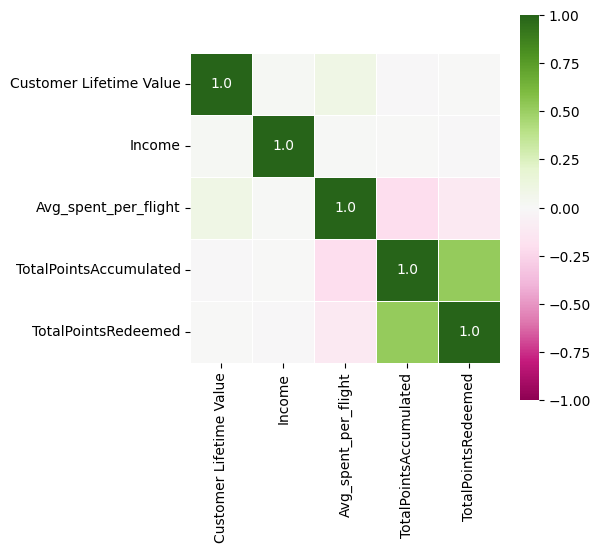

In [7]:
correlation_matrix(value_based_data, 0.7, 5, 5)

In [8]:
value_based_data.to_csv("../data/clustering_data/value_based_data.csv")

## <h1 style="color: #ffffffff; background-color: #1d4e81; text-align: center; padding: 4px; font-family: 'Arial';">Modelling</h1>

### Methodology Overview

**Scaling Approach:** We test three different scaling methods (StandardScaler, MinMaxScaler, RobustScaler) because customer value features vary significantly in range and distribution. We empirically determine which scaler best reveals natural customer value clusters in our specific dataset, rather than assuming one method will work optimally. <br>

**Hierarchical filtering approach**: progressively identifies and extract clear customer segments, through multiple examinations. <br>

This approach allows us to:
- Avoid forcing ambiguous customers into inappropriate segments; <br>
- Achieve higher precision for clear segments; <br>
- Better resolve transitional or mixed behavioral patterns in later iterations, <br>
- Understands the better scaling method in pratical terms. <br>

<!-- ## <h2 style="color: #1322f8ff; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Perspective 1: VALUE-BASED SEGMENTATION</h2> -->

## <h2 style="color: #333333; background-color: #d6fff4; text-align: center; padding:4px; font-family: 'Arial';">Filtering: Examination 1</h2>

In [9]:
value_based_data = value_based_data.copy()

In [10]:
for column in value_based_data.columns:
    if column.startswith('Total_Spend_Month_'):
        value_based_data[column] = np.sqrt(value_based_data[column])

In [11]:
#adicionei por um erro, rever funcções
st_scaler = StandardScaler().set_output(transform="pandas")
mm_scaler = MinMaxScaler().set_output(transform="pandas")
rb_scaler = RobustScaler().set_output(transform="pandas")

# necessário
value_st_scl = st_scaler.fit_transform(value_based_data)
value_mm_scl = mm_scaler.fit_transform(value_based_data)
value_rb_scl = rb_scaler.fit_transform(value_based_data)

## 1. Standard Scaling

### 1.1 K-Means

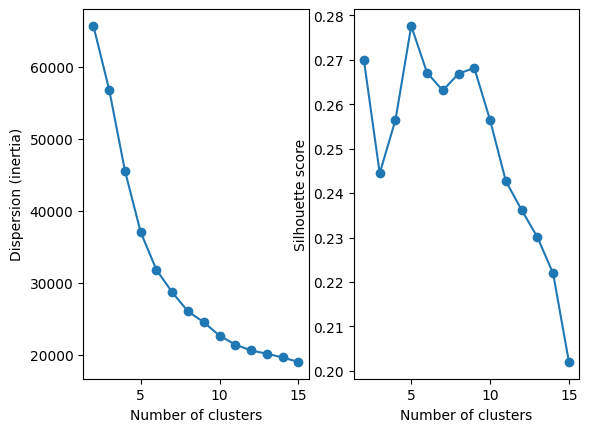

In [12]:
plot_inertia_and_silhouette(value_st_scl)

In [13]:
kmeans_st_scl = KMeans(n_clusters=5, random_state=42).fit(value_st_scl)
data['st_scaled_km_cluster5'] = kmeans_st_scl.predict(value_st_scl)

In [14]:
value_st_scl['st_scaled_km_cluster5'] = data['st_scaled_km_cluster5'] 
groupby_mean(value_st_scl, 'st_scaled_km_cluster5', n_features=4)  

st_scaled_km_cluster5,0,1,2,3,4
Customer Lifetime Value,-0.248782,2.855795,-0.193913,0.804956,-0.197266
Income,-0.765804,-0.026584,1.051028,0.136024,-0.044699
Avg_spent_per_flight,-0.138409,0.019501,-0.134044,12.607438,0.107075
TotalPointsAccumulated,0.585764,0.078237,0.539858,-1.567598,-1.251259
TotalPointsRedeemed,0.429103,0.003822,0.293304,-0.903380,-0.809141


### 1.2 Hierarchical - Ward

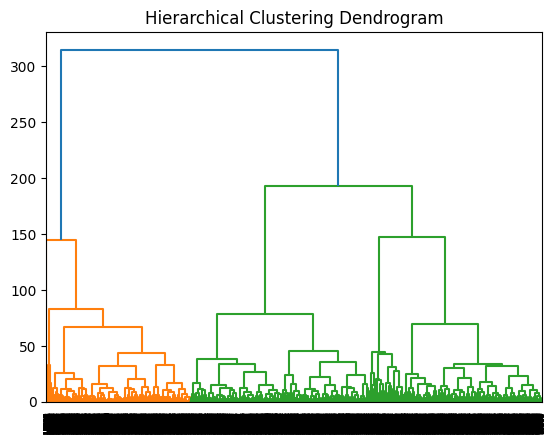

In [15]:
plot_dendrogram(value_st_scl, 'ward')

In [16]:
data['st_scaled_ward_cluster5'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 5
    ).fit_predict(value_st_scl)

In [17]:
value_st_scl['st_scaled_ward_cluster5'] = data['st_scaled_ward_cluster5']
groupby_mean(value_st_scl, 'st_scaled_ward_cluster5', n_features=4)

st_scaled_ward_cluster5,0,1,2,3,4
Customer Lifetime Value,-0.194109,-0.194315,-0.250846,2.847809,1.259852
Income,-0.044593,1.051074,-0.765250,-0.033933,0.339463
Avg_spent_per_flight,0.163050,-0.137004,-0.138410,0.018555,16.065588
TotalPointsAccumulated,-1.252376,0.540034,0.585352,0.083444,-1.571308
TotalPointsRedeemed,-0.808474,0.292857,0.425865,0.023255,-0.924503


## 2. MinMax Scaling

### 2.1 K-Means

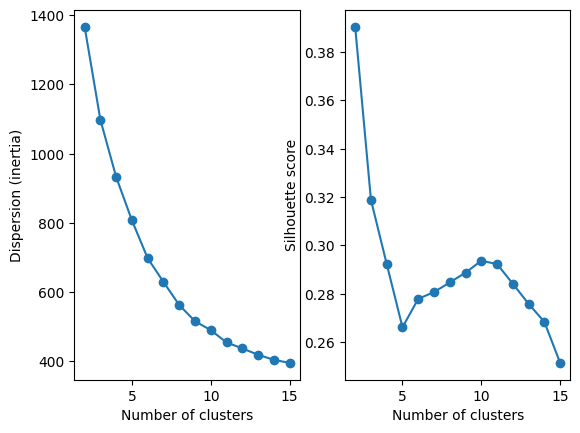

In [18]:
plot_inertia_and_silhouette(value_mm_scl)

In [19]:
#anteriormente fiz com 8, ficou boa mas senti q ainda podia estar melhor portanto testei 10 para filtrar mais numa 2ª examinação
kmeans_mm_scl = KMeans(n_clusters=5, random_state=42).fit(value_mm_scl)
data['mm_scaled_km_cluster5'] = kmeans_mm_scl.predict(value_mm_scl)

In [20]:
value_mm_scl['mm_scaled_km_cluster5'] = data['mm_scaled_km_cluster5']  
groupby_mean(value_mm_scl, 'mm_scaled_km_cluster5', n_features=4)

mm_scaled_km_cluster5,0,1,2,3,4
Customer Lifetime Value,0.069925,0.077354,0.075723,0.076970,0.072817
Income,0.020701,0.669929,0.761693,0.349361,0.151708
Avg_spent_per_flight,0.001082,0.015877,0.001200,0.000988,0.014113
TotalPointsAccumulated,0.362192,0.091214,0.369093,0.362365,0.077211
TotalPointsRedeemed,0.219620,0.030814,0.222281,0.211648,0.026675


### 2.2 Hierarchical - Ward

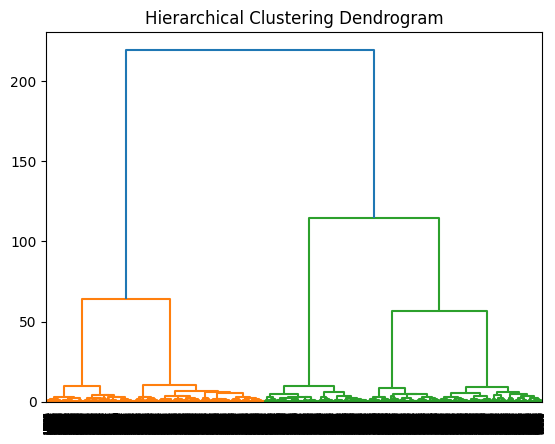

In [21]:
plot_dendrogram(value_mm_scl, 'ward')

In [22]:
data['mm_scaled_ward_cluster5'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 5
    ).fit_predict(value_mm_scl)

In [23]:
value_mm_scl['mm_scaled_ward_cluster5'] = data['mm_scaled_ward_cluster5']
groupby_mean(value_mm_scl, 'mm_scaled_ward_cluster5', n_features=4)

mm_scaled_ward_cluster5,0,1,2,3,4
Customer Lifetime Value,0.076970,0.072817,0.069925,0.075723,0.077354
Income,0.349361,0.151708,0.020701,0.761693,0.669929
Avg_spent_per_flight,0.000988,0.014113,0.001082,0.001200,0.015877
TotalPointsAccumulated,0.362365,0.077211,0.362192,0.369093,0.091214
TotalPointsRedeemed,0.211648,0.026675,0.219620,0.222281,0.030814


## 3. Robust Scaling

### 3.1 K-Means

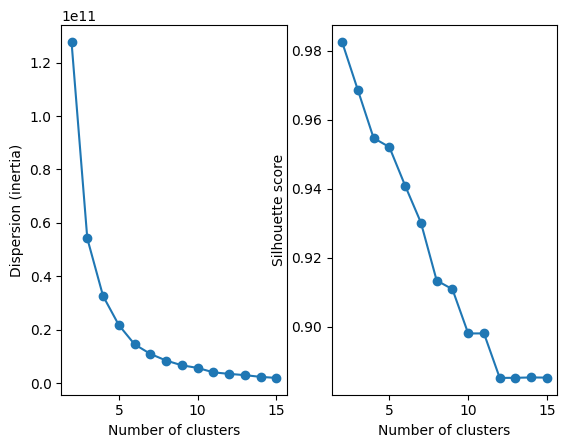

In [24]:
plot_inertia_and_silhouette(value_rb_scl)


In [25]:
kmeans_rb_scl = KMeans(n_clusters=5, random_state=42).fit(value_rb_scl)
data['rb_scaled_km_cluster5'] = kmeans_rb_scl.predict(value_rb_scl)

In [26]:
value_rb_scl['rb_scaled_km_cluster5'] = data['rb_scaled_km_cluster5']
groupby_mean(value_rb_scl, 'rb_scaled_km_cluster5', n_features=4)

rb_scaled_km_cluster5,0,1,2,3,4
Customer Lifetime Value,0.421499,2.464891,1.086603,1.155840,1.271261
Income,0.057192,0.280073,0.005006,0.097193,0.056336
Avg_spent_per_flight,137.841141,67454.494643,31342.524126,10746.640993,105361.948858
TotalPointsAccumulated,-0.135705,-1.116006,-1.116751,-1.054871,-1.177837
TotalPointsRedeemed,0.162336,-0.431945,-0.394039,-0.358837,-0.479130


### 3.2 Hierarchical - Ward

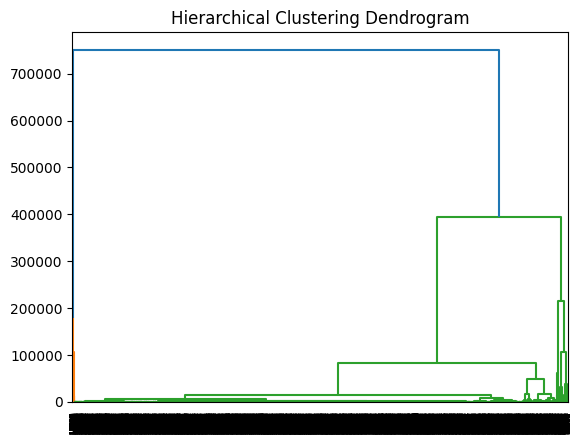

In [27]:
plot_dendrogram(value_rb_scl, 'ward')


In [28]:
data['rb_scaled_ward_cluster5'] = AgglomerativeClustering(
    linkage='ward', n_clusters=5
).fit_predict(value_rb_scl)

In [29]:
value_rb_scl['rb_scaled_ward_cluster5'] = data['rb_scaled_ward_cluster5']
groupby_mean(value_rb_scl, 'rb_scaled_ward_cluster5', n_features=4)

rb_scaled_ward_cluster5,0,1,2,3,4
Customer Lifetime Value,1.147054,2.048155,0.421199,1.086764,1.354758
Income,0.095278,0.212920,0.057083,0.024439,0.024917
Avg_spent_per_flight,10979.177971,66162.986168,133.344679,31657.164408,109429.636731
TotalPointsAccumulated,-1.055654,-1.129615,-0.134910,-1.120107,-1.183535
TotalPointsRedeemed,-0.356687,-0.442834,0.162778,-0.402253,-0.479130


## 4. Cluster Visualization 1

In [30]:
clusters_km = ['st_scaled_km_cluster5', 'mm_scaled_km_cluster5', 'rb_scaled_km_cluster5']

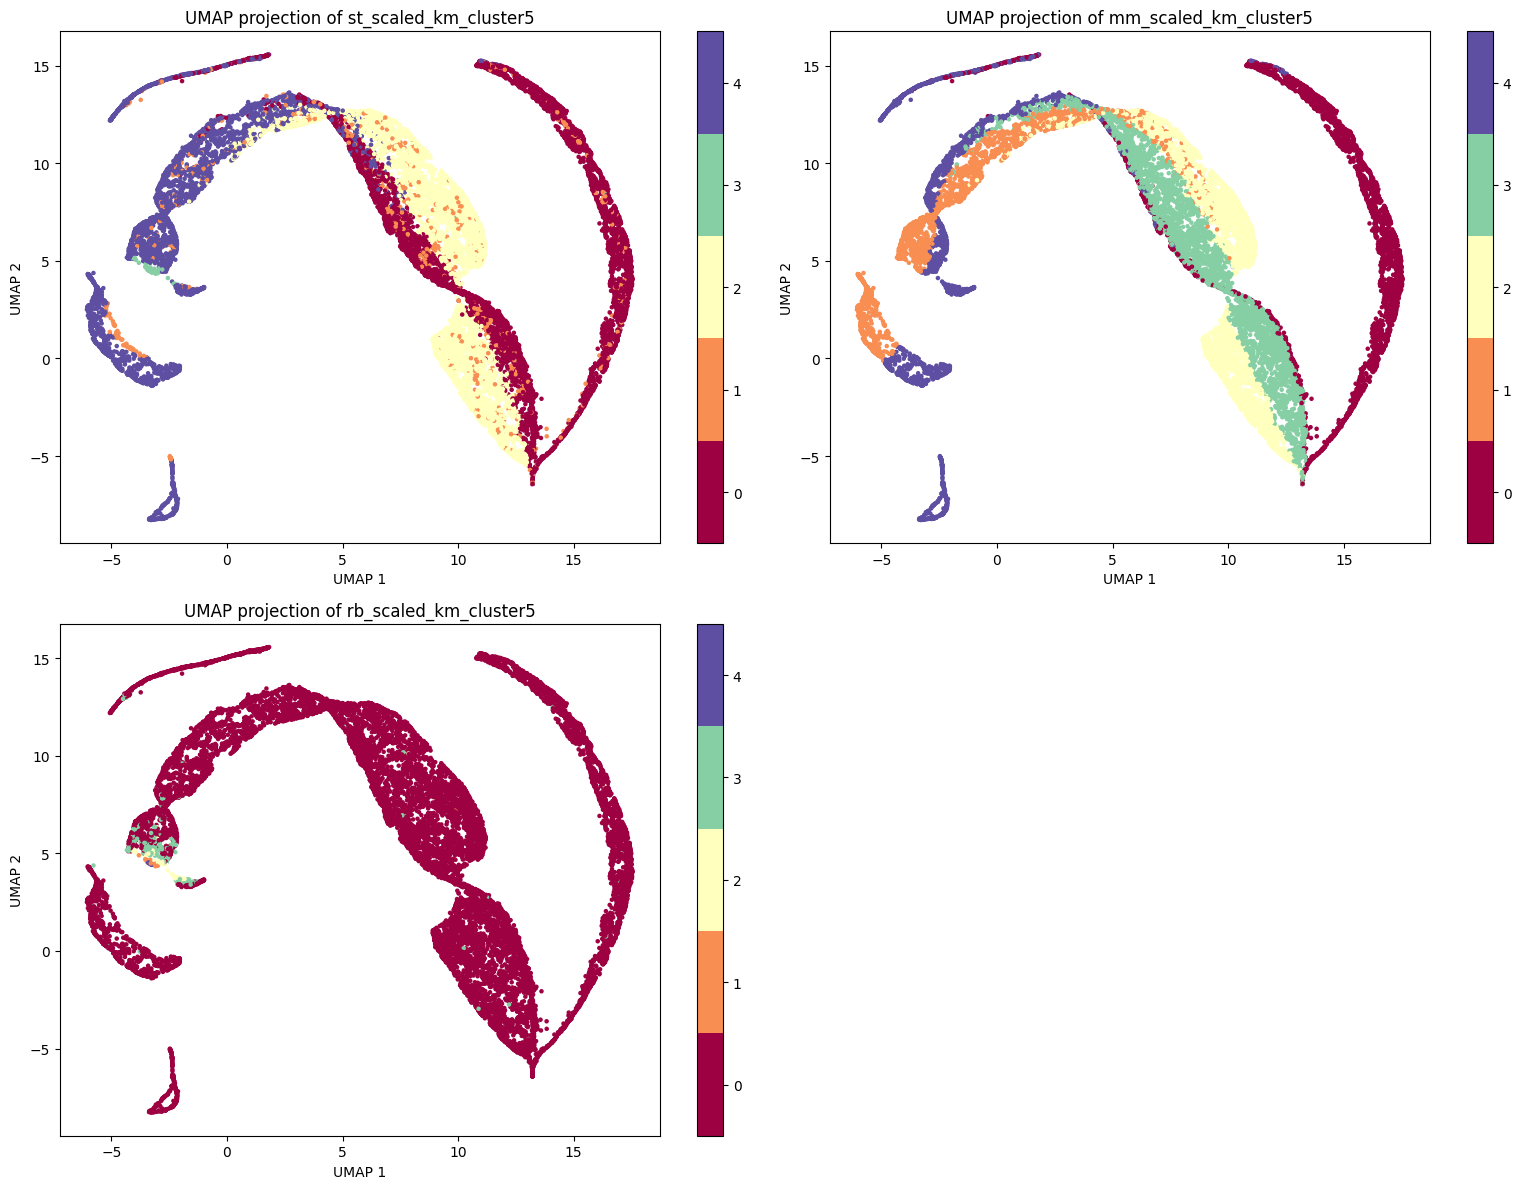

In [31]:
plot_umap_projections(data, clusters_km)

In [32]:
cluster_ward = ['st_scaled_ward_cluster5', 'mm_scaled_ward_cluster5', 'rb_scaled_ward_cluster5']

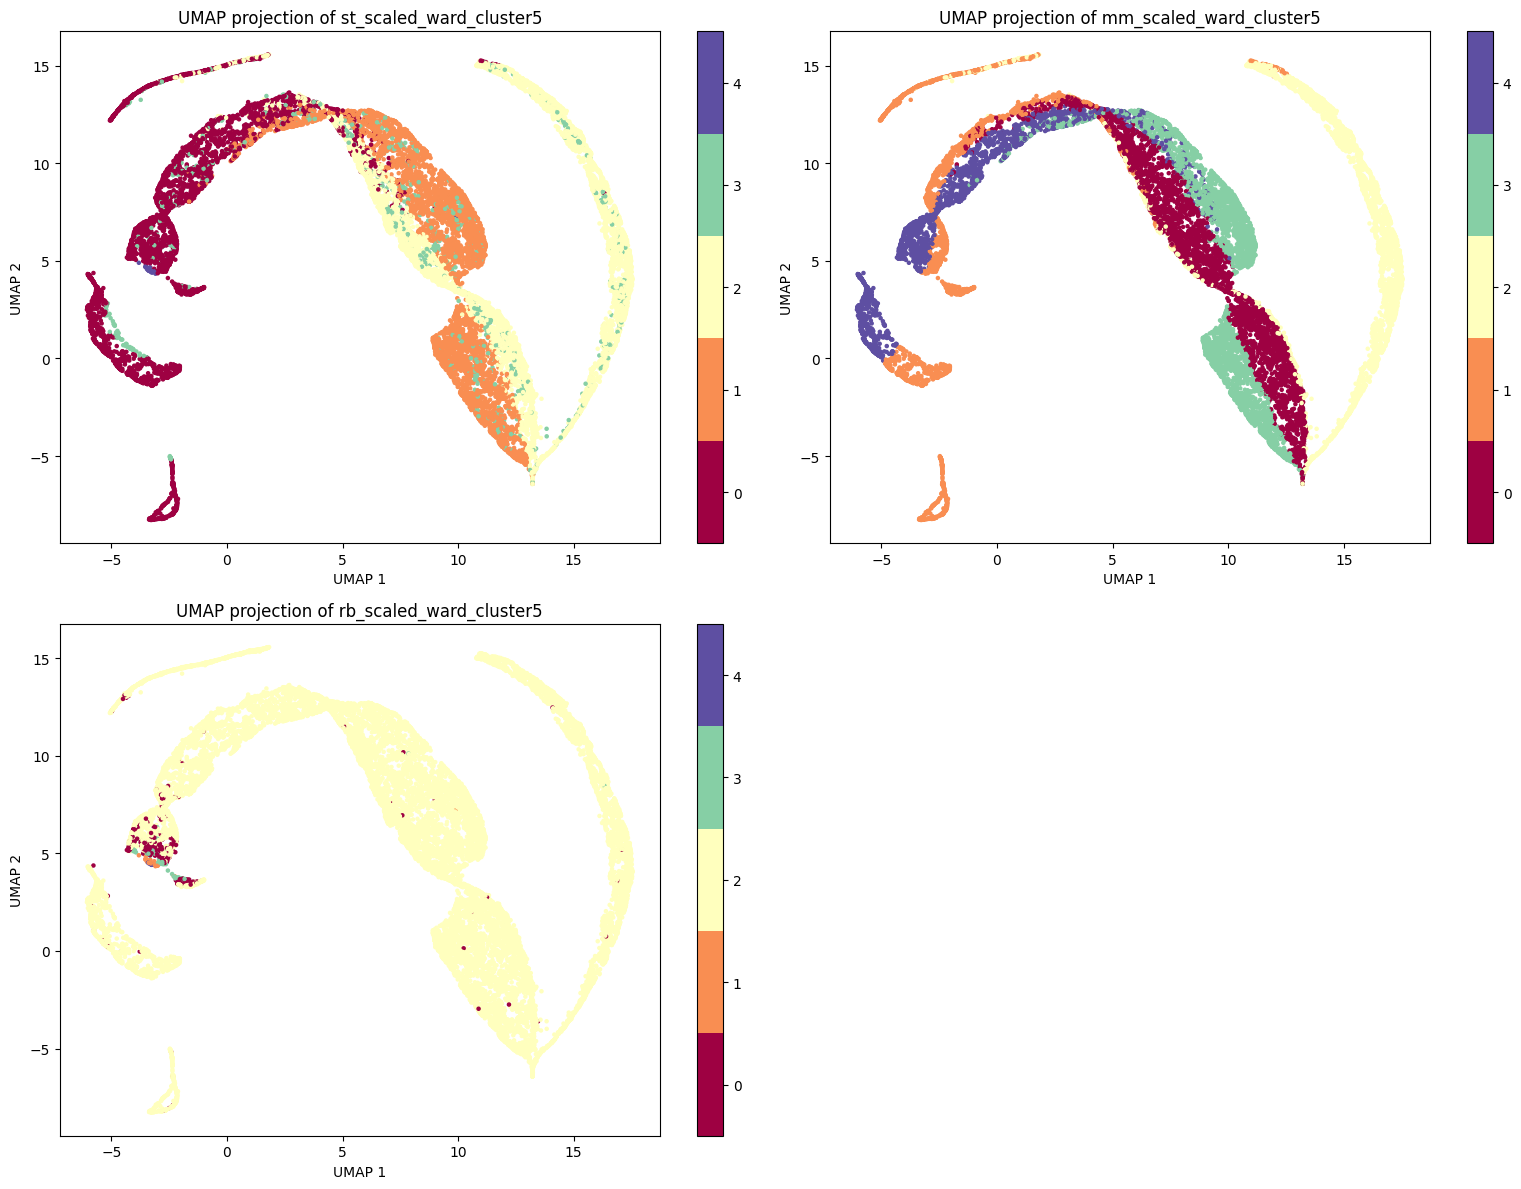

In [33]:
plot_umap_projections(data, cluster_ward)

In [34]:
groupby_mean(data, 'mm_scaled_km_cluster5', n_features = 30)

mm_scaled_km_cluster5,0,1,2,3,4
Income,2069.721126,66980.180122,76154.859772,34929.475646,15167.905253
Customer Lifetime Value,7591.855604,8196.751428,8063.964928,8165.511605,7827.313790
EnrollmentType,0.041497,0.122515,0.038563,0.048251,0.116689
rejoined_program,0.000580,0.034888,0.000000,0.000229,0.034574
Days_in_prog,1377.112014,510.301826,1405.716039,1383.967985,461.208112
Cancelled_program,0.032501,0.296957,0.030383,0.029042,0.323471
Enrollment_year,2017.704295,2019.417850,2017.623138,2017.689001,2019.446809
Enrollment_month,6.506094,6.879513,6.586328,6.514064,6.980053
TotalFlights,191.359402,51.629087,192.677125,190.054471,43.761536
TotalDistance,383846.013784,96672.049087,391158.261262,384029.163595,81830.949402


### 4.1 Cluster Extraction 1

We will extract **Clusters 2 and 4** as they demonstrate:
- Clear, distinct behavioral patterns
- Minimal overlap with other segments in UMAP space

**Cluster 2 - Description:**
- Mid-range income, indicating value is driven more by behavior than purchasing power;
- Highly frequent and active users, with sustained travel activity and recent engagement;
- High customer value, supported by strong lifetime value and consistent contribution over time;
- Strong loyalty program engagement, actively earning and redeeming points, reflecting habitual and well-integrated usage rather than opportunistic behavior.
<br><br>

**Cluster 4 - Description:**
- **Lowest income** with a value of 0.0105, they are significantly more price-sensitive; 
- **Efficient Spending** with a relatively low Avg_spent_per_flight (0.001), suggesting they are likely budget-conscious travelers who maximize value or perhaps travel on discounted fares while ensuring they rack up points;
- Relative **high Total Points Accumulated** but **low Redemption** - "hoarding" behavior, they are possibly accumulating points but haven't yet cashed them in, perhaps saving for a high-value aspirational reward.


In [35]:
# Low Income but High Activity -> Value driven by habitual engagement, not income
Behavior_sustained_value = data[data['mm_scaled_km_cluster5'] == 2]
# Mid-Range Income, frequent Core Loyalists -> Value maximized through cost discipline and reward strategy
Efficiency_Optimized_Value = data[data['mm_scaled_km_cluster5'] == 4]

### 4.2 Preparation for next extraction

In [36]:
# List of cluster labels to exclude
exclude_clusters = [2,4]

# Filter the original dataset to exclude rows with specified cluster labels
data_filtered1 = data[~data['mm_scaled_km_cluster5'].isin(exclude_clusters)]

In [37]:
data_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__4,Location__5,Location__6,Location__7,st_scaled_km_cluster5,st_scaled_ward_cluster5,mm_scaled_km_cluster5,mm_scaled_ward_cluster5,rb_scaled_km_cluster5,rb_scaled_ward_cluster5
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100102,0.0,2887.74,0,0,2122.0,0,2016,3,247.7,339114.6,...,0,0,0,0,0,2,0,2,0,2
100140,0.0,2838.07,0,0,884.0,0,2019,7,216.8,432030.8,...,0,1,0,0,0,2,0,2,0,2
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,112.3,364601.7,...,0,0,0,0,2,1,3,0,0,2
100301,52499.0,48356.96,0,0,1930.0,0,2016,9,238.6,456142.3,...,0,0,0,0,1,3,3,0,0,2
100380,51641.0,2465.62,0,0,2254.0,0,2015,10,169.1,367306.4,...,1,0,0,0,2,1,3,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999731,69600.0,2951.29,0,0,1571.0,1,2016,9,108.3,195054.0,...,0,0,0,0,2,1,1,4,0,2
999788,33397.0,8409.07,0,0,243.0,1,2020,2,79.8,213959.0,...,0,0,0,0,4,0,3,0,0,2
999891,59732.0,3745.37,0,0,245.0,1,2019,5,1.9,42026.1,...,0,0,0,0,4,0,1,4,3,0


In [38]:
data_filtered1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10284 entries, 100102 to 999986
Data columns (total 69 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Income                          10284 non-null  float64
 1   Customer Lifetime Value         10284 non-null  float64
 2   EnrollmentType                  10284 non-null  int64  
 3   rejoined_program                10284 non-null  int64  
 4   Days_in_prog                    10284 non-null  float64
 5   Cancelled_program               10284 non-null  int64  
 6   Enrollment_year                 10284 non-null  int64  
 7   Enrollment_month                10284 non-null  int64  
 8   TotalFlights                    10284 non-null  float64
 9   TotalDistance                   10284 non-null  float64
 10  TotalPointsAccumulated          10284 non-null  float64
 11  TotalPointsRedeemed             10284 non-null  float64
 12  Flights_per_day                

In [39]:
data_filtered1 = data_filtered1.loc[:, ~data_filtered1.columns.str.startswith(("st_", "mm_", "rb_"))]

In [40]:
data_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Marital_Married,Marital_Single,Location__0,Location__1,Location__2,Location__3,Location__4,Location__5,Location__6,Location__7
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100102,0.0,2887.74,0,0,2122.0,0,2016,3,247.7,339114.6,...,0,1,0,1,0,0,0,0,0,0
100140,0.0,2838.07,0,0,884.0,0,2019,7,216.8,432030.8,...,0,0,0,0,0,0,0,1,0,0
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,112.3,364601.7,...,1,0,0,0,1,0,0,0,0,0
100301,52499.0,48356.96,0,0,1930.0,0,2016,9,238.6,456142.3,...,0,0,0,1,0,0,0,0,0,0
100380,51641.0,2465.62,0,0,2254.0,0,2015,10,169.1,367306.4,...,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999731,69600.0,2951.29,0,0,1571.0,1,2016,9,108.3,195054.0,...,1,0,0,0,1,0,0,0,0,0
999788,33397.0,8409.07,0,0,243.0,1,2020,2,79.8,213959.0,...,1,0,0,1,0,0,0,0,0,0
999891,59732.0,3745.37,0,0,245.0,1,2019,5,1.9,42026.1,...,1,0,0,0,0,1,0,0,0,0


## <h2 style="color: #333333; background-color: #d6fff4; text-align: center; padding: 6px; font-family: 'Arial';">Filtering: Examination 2</h2>

## Re-Scaling Data

In [41]:
data_filtered2 = data_filtered1.copy()


In [42]:
value_based_data_2 = data_filtered2[["Customer Lifetime Value", "Income", "Avg_spent_per_flight", "TotalPointsAccumulated", 
                              "TotalPointsRedeemed"]].copy()

In [43]:
value_st_scl_2 = st_scaler.fit_transform(value_based_data_2)
value_rb_scl_2 = rb_scaler.fit_transform(value_based_data_2)

## 1. Standard Scaling

### 1.1 K-Means

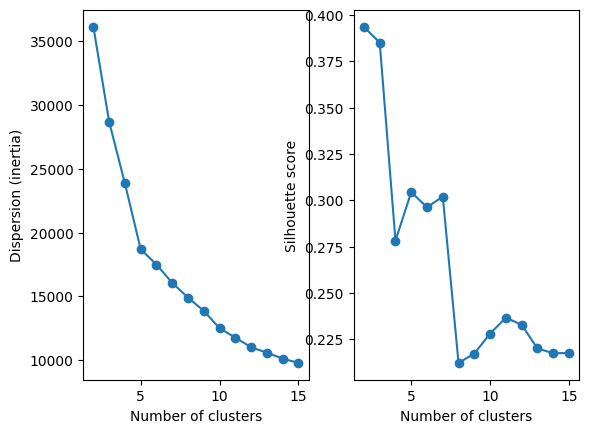

In [44]:
plot_inertia_and_silhouette(value_st_scl_2)

In [45]:
# MUDAR NUMERO DE CLUSTERS !!!!!!!!!!
kmeans_st_scl_2 = KMeans(n_clusters=2, random_state=42).fit(value_st_scl_2)
data_filtered2['st_scaled_km2_cluster2'] = kmeans_st_scl_2.predict(value_st_scl_2)

In [46]:
value_st_scl_2['st_scaled_km2_cluster2'] = data_filtered2['st_scaled_km2_cluster2'] 
groupby_mean(value_st_scl_2, 'st_scaled_km2_cluster2', n_features=4)  

st_scaled_km2_cluster2,0,1
Customer Lifetime Value,-0.003349,1.009531
Income,-0.004506,1.358372
Avg_spent_per_flight,-0.049625,14.960436
TotalPointsAccumulated,0.006356,-1.916295
TotalPointsRedeemed,0.003498,-1.054578


### 1.2 Hierarchical - Ward

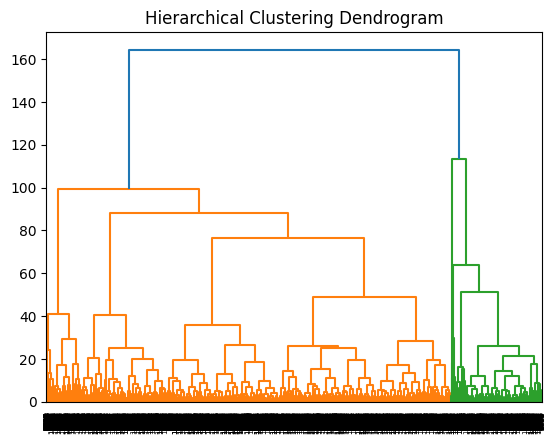

In [47]:
plot_dendrogram(value_st_scl_2, 'ward')

In [48]:
data_filtered2['st_scaled_ward2_cluster3'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 3
    ).fit_predict(value_st_scl_2)

In [49]:
value_st_scl_2['st_scaled_ward2_cluster3'] = data_filtered2['st_scaled_ward2_cluster3']
groupby_mean(value_st_scl_2, 'st_scaled_ward2_cluster3', n_features=4)

st_scaled_ward2_cluster3,0,1,2
Customer Lifetime Value,-0.018332,0.068370,1.402563
Income,-0.310837,1.389800,1.181907
Avg_spent_per_flight,-0.113702,0.321749,18.731768
TotalPointsAccumulated,0.373275,-1.663775,-1.928794
TotalPointsRedeemed,0.211952,-0.945000,-1.067595


## 2. Robust Scaling

### 2.1 K-Means

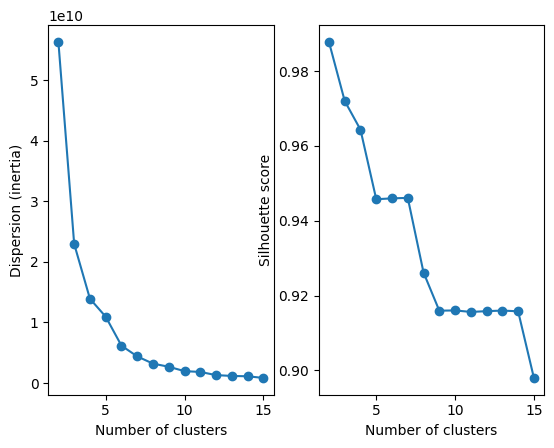

In [50]:
plot_inertia_and_silhouette(value_rb_scl_2)

In [51]:
kmeans_rb_scl_2 = KMeans(n_clusters=3, random_state=42).fit(value_rb_scl_2)
data_filtered2['rb_scaled_km2_cluster3'] = kmeans_rb_scl_2.predict(value_rb_scl_2)

In [52]:
value_rb_scl_2['rb_scaled_km2_cluster3'] = data_filtered2['rb_scaled_km2_cluster3']
groupby_mean(value_rb_scl_2, 'rb_scaled_km2_cluster3', n_features=4)

rb_scaled_km2_cluster3,0,1,2
Customer Lifetime Value,0.439659,2.277450,1.138992
Income,0.031920,0.720487,0.699357
Avg_spent_per_flight,139.340188,79980.465334,18399.786823
TotalPointsAccumulated,-0.162080,-1.777299,-1.659906
TotalPointsRedeemed,0.113146,-0.539206,-0.443629


### 2.2 Hierarchical - Ward

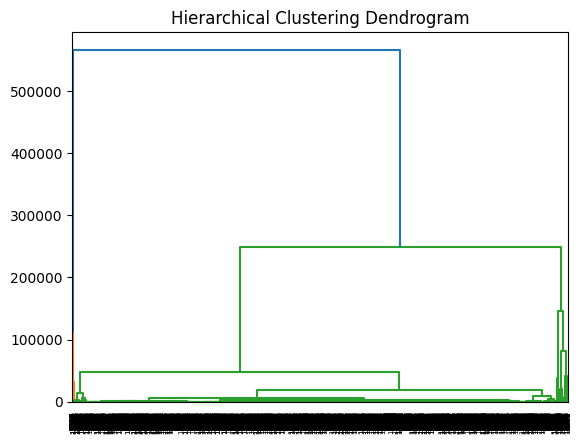

In [53]:
plot_dendrogram(value_rb_scl_2, 'ward')


In [54]:
data_filtered2['rb_scaled_ward2_cluster2'] = AgglomerativeClustering(
    linkage='ward', n_clusters=2
).fit_predict(value_rb_scl_2)

In [55]:
value_rb_scl_2['rb_scaled_ward2_cluster2'] = data_filtered2['rb_scaled_ward2_cluster2']
groupby_mean(value_rb_scl_2, 'rb_scaled_ward2_cluster2', n_features=4)

rb_scaled_ward2_cluster2,0,1
Customer Lifetime Value,0.447614,2.123798
Income,0.039377,0.703984
Avg_spent_per_flight,336.751007,77524.420396
TotalPointsAccumulated,-0.178695,-1.781118
TotalPointsRedeemed,0.106977,-0.539206


## 3. Cluster Visualization 2

In [56]:
clusters_km2 = ['st_scaled_km2_cluster2', 'rb_scaled_km2_cluster3']

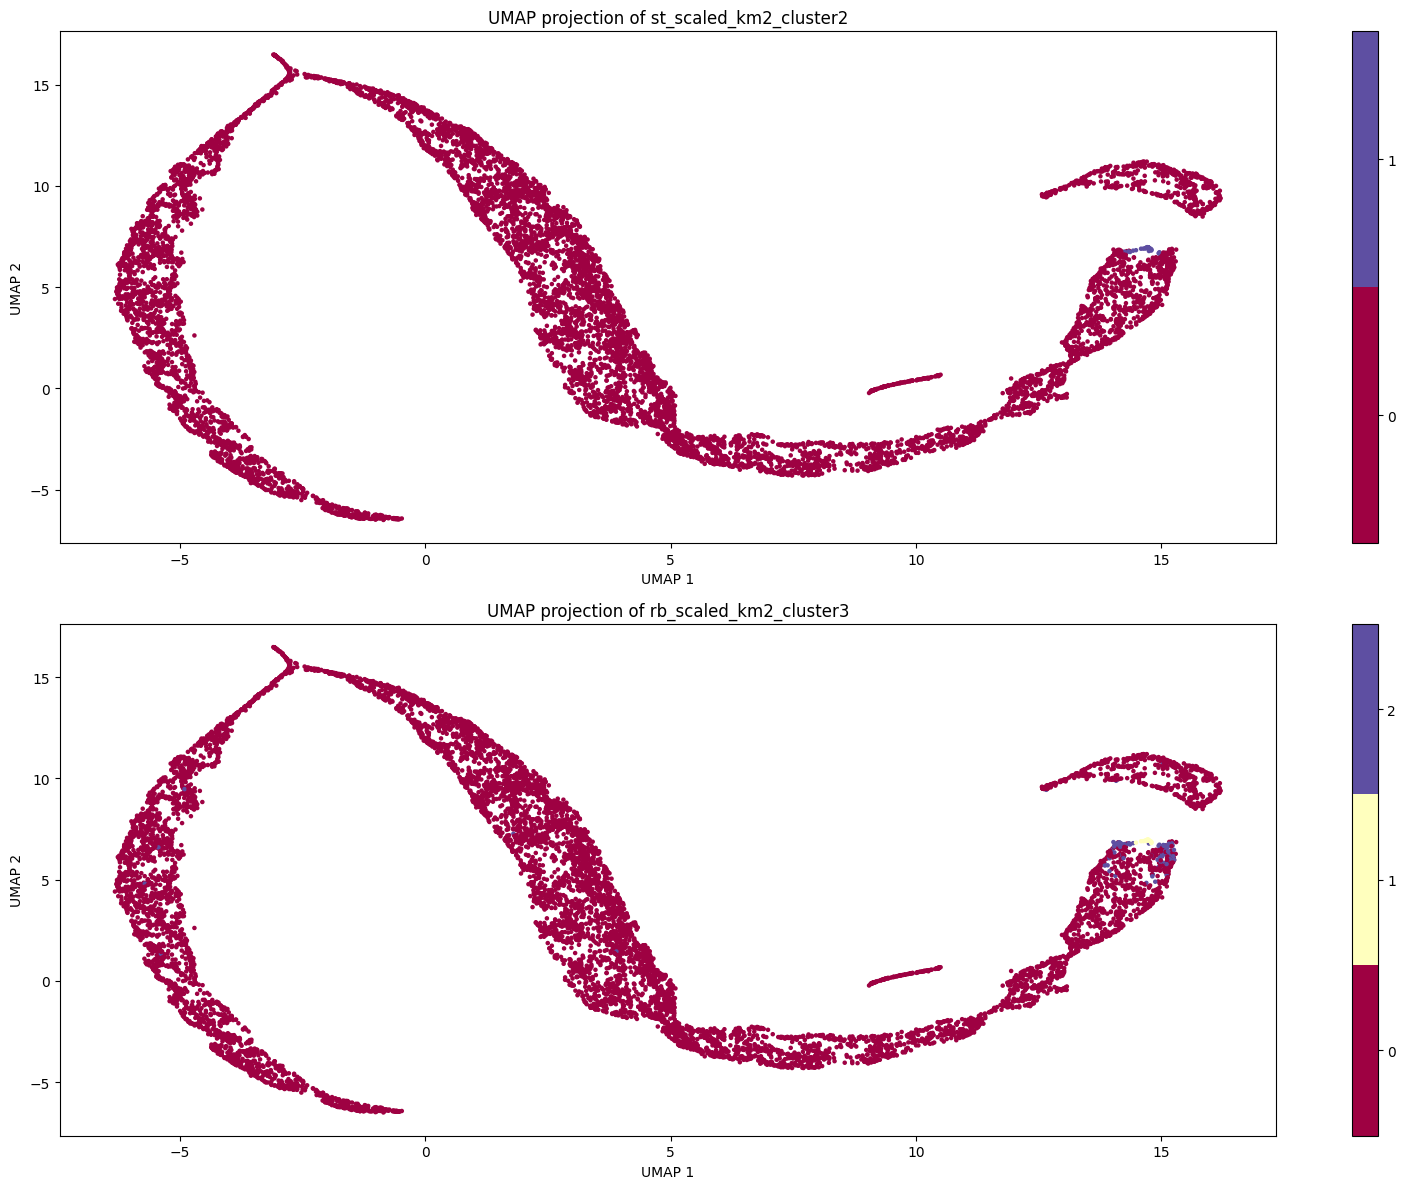

In [57]:
plot_umap_projections(data_filtered2, clusters_km2)

In [58]:
cluster_ward2 = ['st_scaled_ward2_cluster3', 'rb_scaled_ward2_cluster2']

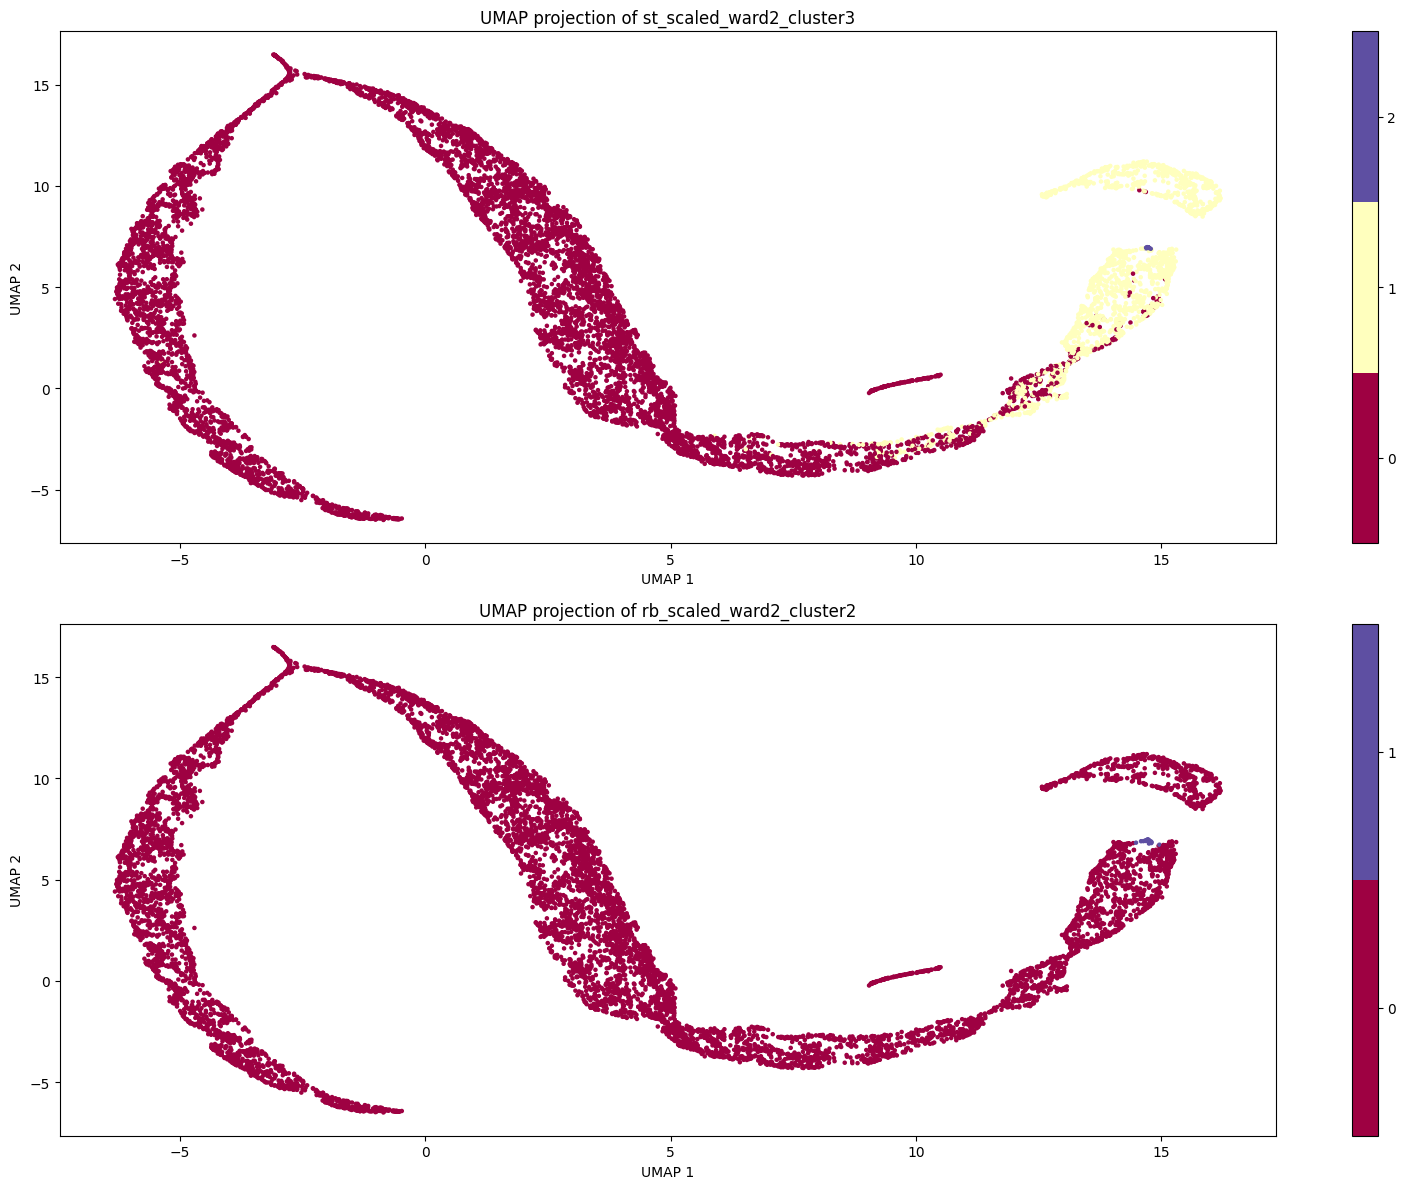

In [59]:
plot_umap_projections(data_filtered2, cluster_ward2)

In [60]:
groupby_mean(data_filtered2, 'st_scaled_km2_cluster2')

st_scaled_km2_cluster2,0,1
Income,31481.169171,67735.764706
Customer Lifetime Value,7957.794339,14909.322353
EnrollmentType,0.064000,0.000000
rejoined_program,0.008195,0.147059
Days_in_prog,1175.936293,63.735294
Cancelled_program,0.094634,0.029412
Enrollment_year,2018.099122,2020.941176
Enrollment_month,6.586439,10.382353
TotalFlights,157.819268,4.438235
TotalDistance,316067.872117,20406.108824


### 3.1 Cluster Extraction 2

ADICIONAR DESCRIÇÃO DOS CLUSTERS

In [61]:
# Cluster 0 - Value exists but is unstable and at risk
Fragile_Value_Contributers = data_filtered2[data_filtered2['st_scaled_km2_cluster2'] == 0]

# Cluster 1 - value driven by spending power + sustained usage
Premium_driven_value = data_filtered2[data_filtered2['st_scaled_km2_cluster2'] == 1]

In [62]:
# List of cluster labels to exclude
exclude_clusters2 = [0, 1]

# Filter the original dataset to exclude rows with specified cluster labels
data_filtered3 = data_filtered2[~data_filtered2['st_scaled_km2_cluster2'].isin(exclude_clusters2)]

In [63]:
data_filtered3 = data_filtered3.loc[:, ~data_filtered3.columns.str.startswith(("st_", "mm_", "rb_"))]

In [64]:
# To confirm if all the data ios assigned to a cluster
data_filtered3

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Marital_Married,Marital_Single,Location__0,Location__1,Location__2,Location__3,Location__4,Location__5,Location__6,Location__7
Loyalty#,,,,,,,,,,,,,,,,,,,,,


In [65]:
data['segment'] = 'Unassigned'

data.loc[Behavior_sustained_value.index, 'segment'] = 'Behavior_sustained_value'
data.loc[Efficiency_Optimized_Value.index, 'segment'] = 'Efficiency_Optimized_Value'
data.loc[Fragile_Value_Contributers.index, 'segment'] = 'Fragile_Value_Contributers'
data.loc[Premium_driven_value.index, 'segment'] = 'Premium_driven_value'

NOTA!!!!!!!!!!

Falta atualizar isto - preciso de voltar a correr o código, ele não está a assumir todos os clusters

In [66]:
data['segment'].value_counts()

segment
Fragile_Value_Contributers    10250
Behavior_sustained_value       3423
Efficiency_Optimized_Value     3008
Premium_driven_value             34
Name: count, dtype: int64

In [67]:
segment_dummies = pd.get_dummies(
    data['segment'],
    prefix='seg',
    dtype=int
)

In [68]:
people = pd.concat([data, segment_dummies], axis=1)

In [69]:
people.drop(columns=['segment'], inplace=True)

In [70]:
people = people.loc[:, ~people.columns.str.startswith(("st_", "mm_", "rb_"))]

In [71]:
people

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__2,Location__3,Location__4,Location__5,Location__6,Location__7,seg_Behavior_sustained_value,seg_Efficiency_Optimized_Value,seg_Fragile_Value_Contributers,seg_Premium_driven_value
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,0,1,0,0,0,0,1,0,0
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,0,0,0,1,0,0,0,1,0,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,0,0,1,0,0,0,0,1,0,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
